In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import zipfile


from skimage.transform import resize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [ ]:
!kaggle datasets download uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:19<00:00, 23.1MB/s]
100% 429M/429M [00:19<00:00, 22.6MB/s]


In [ ]:
with zipfile.ZipFile("ravdess-emotional-speech-audio.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/ravdess-emotional-speech-audio")

In [ ]:
# Fungsi untuk mengekstraksi fitur Mel-spectrogram
def extract_features(file, sample_rate=22050, n_mels=128, fmax=8000, resize_shape=(300, 300)):
    audio_data, sr = librosa.load(file, sr=sample_rate)
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr, n_mels=n_mels, fmax=fmax)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    resized_spectrogram = resize(log_mel_spectrogram, resize_shape)
    resized_spectrogram = np.expand_dims(resized_spectrogram, axis=-1)
    return np.repeat(resized_spectrogram, 3, axis=-1)

In [ ]:
# Membuat DataFrame dari dataset RAVDESS
def process_ravdess_dataset(dataset_path):
    emotions = []
    features = []

    # Mapping untuk emosi dalam RAVDESS
    emotion_mapping = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }

    # Menelusuri semua file audio di folder dataset
    for root, _, files in os.walk(dataset_path):
        for file in tqdm(files, desc="Processing RAVDESS Dataset"):
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                # Ekstraksi emosi dari nama file (format: Actor_XX_Emotion_YY_...)
                emotion_code = file.split('-')[2]
                emotion_label = emotion_mapping.get(emotion_code, 'unknown')
                if emotion_label != 'unknown':  # Abaikan file dengan label yang tidak diketahui
                    features.append(extract_features(file_path))
                    emotions.append(emotion_label)

    # Membuat DataFrame
    return pd.DataFrame({
        'spectrogram': features,
        'class': emotions
    })

# Contoh penggunaan
dataset_path = '/content/ravdess-emotional-speech-audio'  # Ganti dengan path ke dataset RAVDESS Anda
data_df = process_ravdess_dataset(dataset_path)

print(data_df.head())

Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 44.85it/s]
Processing RAVDESS Dataset: 0it [00:00, ?it/s]
Processing RAVDESS Dataset: 100%|██████████| 60/60 [00:01<00:00, 48.47it/s]


                                         spectrogram      class
0  [[[-79.76592, -79.76592, -79.76592], [-79.7596...       calm
1  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...  surprised
2  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...      angry
3  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...    disgust
4  [[[-80.0, -80.0, -80.0], [-80.0, -80.0, -80.0]...      happy


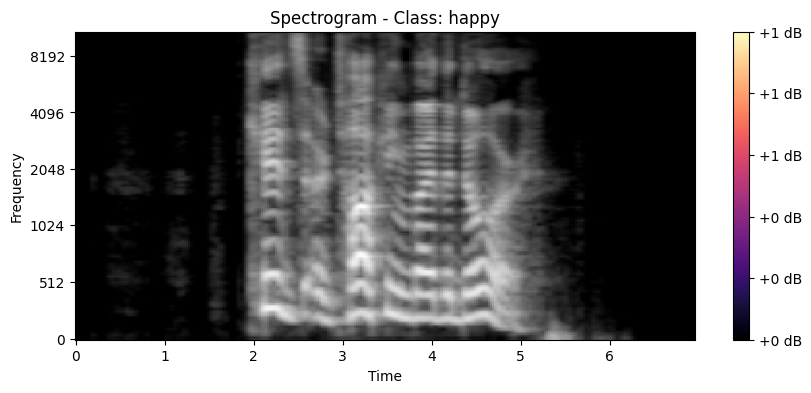

In [ ]:
#Nenasukkan data index yang inginkan
random_index=10
# Modifikasi fungsi visualisasi untuk menormalkan spektrogram
def visualize_spectrogram(spectrogram, label):
    # Normalisasi nilai spektrogram ke rentang 0..1
    spectrogram = (spectrogram - np.min(spectrogram)) / (np.max(spectrogram) - np.min(spectrogram))

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=22050, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Class: {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

# Menampilkan spektrogram dari contoh dengan indeks acak
visualize_spectrogram(data_df['spectrogram'][random_index], data_df['class'][random_index])


In [ ]:
# Menyiapkan data dan label
X = np.array([s for s in data_df['spectrogram']])
y = np.array(data_df['class'])

# Mengkodekan label emosi
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(2304, 300, 300, 3)

In [ ]:
# Mengimpor model EfficientNetB3
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))

# Membekukan lapisan EfficientNetB3 untuk pelatihan transfer learning
base_model.trainable = False

# Menambahkan lapisan kustom di atas EfficientNetB3
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)  # Dropout untuk menghindari overfitting
output = Dense(len(label_encoder.classes_), activation='softmax')(x)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Membuat dan mengompilasi model
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Melatih model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 45s 393ms/step - accuracy: 0.2107 - loss: 2.0289 - val_accuracy: 0.3970 - val_loss: 1.7715
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.3464 - loss: 1.8069 - val_accuracy: 0.4512 - val_loss: 1.6374
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.3749 - loss: 1.7145 - val_accuracy: 0.4642 - val_loss: 1.5468
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.4235 - loss: 1.6047 - val_accuracy: 0.5206 - val_loss: 1.4704
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.4403 - loss: 1.5462 - val_accuracy: 0.5401 - val_loss: 1.4131
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.4643 - loss: 1.4932 - val_accuracy: 0.4902 - val_loss: 1.3794
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.4820 - loss: 1.4334 - val_accuracy: 0.5271 - val_loss: 1.3364
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.4968 - loss: 1.3826 - val_ac

In [ ]:
# Menyimpan model
model.save("EfficientNetB3_emotion_model.h5")

18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.5686 - loss: 1.1735
Test accuracy: 0.5694, Test loss: 1.1655
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step
F1 Score: 0.5582
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.61      0.64        77
           1       0.62      0.77      0.69        77
           2       0.51      0.71      0.59        70
           3       0.56      0.72      0.63        74
           4       0.49      0.35      0.41        79
           5       0.45      0.38      0.41        45
           6       0.49      0.31      0.38        77
           7       0.69      0.65      0.67        77

    accuracy                           0.57       576
   macro avg       0.56      0.56      0.55       576
weighted avg       0.57      0.57      0.56       576



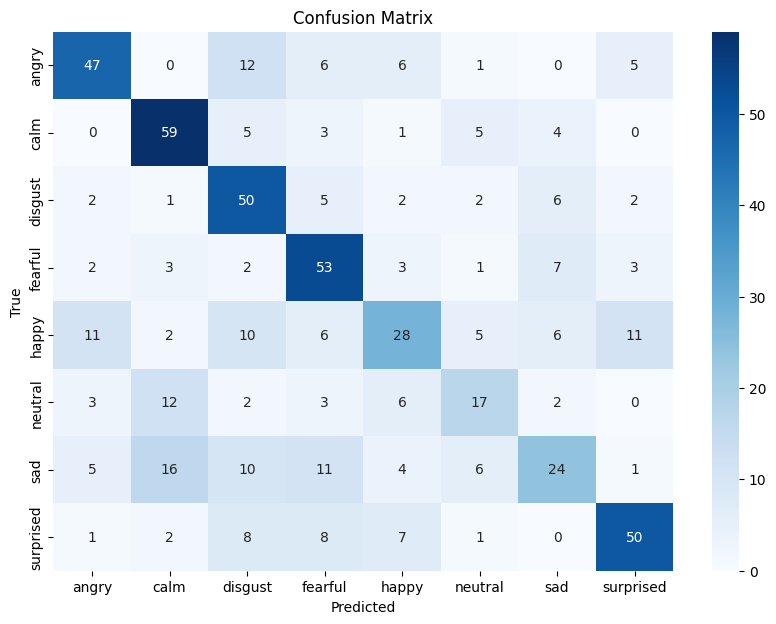

In [ ]:
# Evaluasi model pada set pengujian
loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {loss:.4f}")

# Prediksi untuk data uji
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Mengambil kelas dengan probabilitas tertinggi

# Menghitung F1 Score
f1 = f1_score(y_test, y_pred_classes, average='weighted')  # Menggunakan rata-rata berbobot
print(f"F1 Score: {f1:.4f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

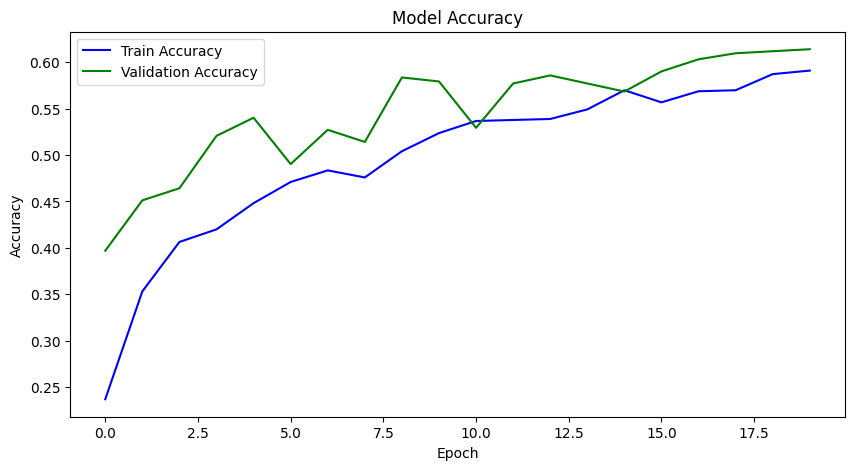

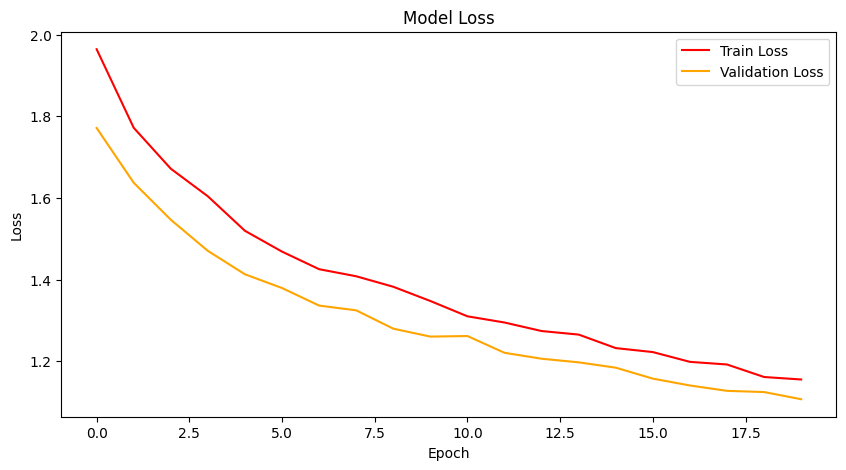

In [ ]:
# Visualisasi akurasi dan kehilangan selama pelatihan
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()